In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

merged = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet")
print(merged.shape)
merged.head()

(66727, 54)


,OBJECT_NAME,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,NORAD_CAT_ID,BSTAR,MEAN_MOTION_DOT,SEMIMAJOR_AXIS,PERIOD,...,rx_km,ry_km,rz_km,vx_km_s,vy_km_s,vz_km_s,tle_age_days,altitude_km,speed_km_s,regime
0,EXPLORER 1,1970-03-31T00:50:24.429408,16.27546304,0.00247390,33.1468,4,0.00000000000000,0.07718844,6577.283,88.476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,VANGUARD 1,2026-03-20T17:10:14.647584,10.85959671,0.18369429,34.2414,5,0.00016070833000,0.00000108,8613.759,132.602,...,-8210.998356,-3990.498411,-1923.840662,2.574536,-4.548402,3.446308,1.0,2958.830356,6.260450,MEO
2,SPUTNIK 3,1960-04-04T03:52:47.964864,16.28328133,0.00883180,65.0599,8,0.00000000000000,0.02607090,6575.177,88.434,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,EXPLORER 4,1959-10-02T06:53:14.055072,15.51612549,0.02545340,50.2549,9,0.00000000000000,0.00892850,6790.158,92.806,...,-3519.404089,3015.901726,-4733.148996,-6.414072,-3.952547,2.200901,24277.0,253.542836,7.849007,VLEO
4,VANGUARD 2,2026-03-21T09:09:17.498592,11.90288286,0.14457065,32.8774,11,0.00046155897000,0.00000908,8102.774,120.979,...,-1388.811012,7840.407708,3589.239802,-5.787650,-1.342493,2.607252,0.0,2363.038666,6.488216,MEO


In [2]:
# redefining risk based on actual orbital properties
# not conjunction data
merged['PERIGEE'] = pd.to_numeric(merged['PERIGEE'], errors='coerce')
merged['BSTAR'] = pd.to_numeric(merged['BSTAR'], errors='coerce')
merged['ECCENTRICITY'] = pd.to_numeric(merged['ECCENTRICITY'], errors='coerce')

def get_risk_label(row):
    # high drag + low perigee = decaying fast = high risk
    if row['PERIGEE'] < 400 and abs(row['BSTAR']) > 0.0001:
        return 'HIGH'
    # medium altitude LEO with some drag
    elif row['PERIGEE'] < 600 and abs(row['BSTAR']) > 0.00001:
        return 'MEDIUM'
    # everything else
    else:
        return 'LOW'

merged['risk_label'] = merged.apply(get_risk_label, axis=1)
print(merged['risk_label'].value_counts())

risk_label
LOW       25421
HIGH      25031
MEDIUM    16275
Name: count, dtype: int64


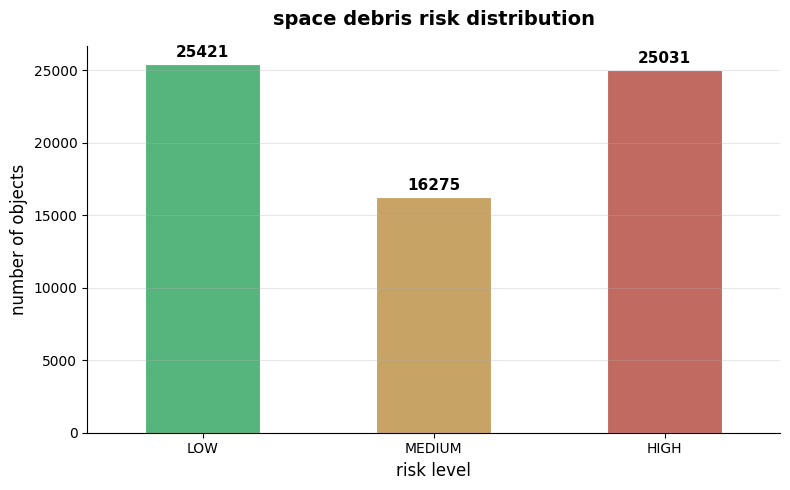

In [3]:
colors = ["#55b57d", "#c8a366", "#c06a61"]
bars = merged['risk_label'].value_counts().reindex(['LOW', 'MEDIUM', 'HIGH'])

plt.figure(figsize=(8, 5))
ax = bars.plot(kind='bar', color=colors, edgecolor='white', linewidth=0.8)

for i, v in enumerate(bars):
    ax.text(i, v + 500, str(v), ha='center', fontweight='bold', fontsize=11)

plt.title('space debris risk distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('risk level', fontsize=12)
plt.ylabel('number of objects', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [4]:
features = [
    'ECCENTRICITY', 'INCLINATION', 'MEAN_MOTION',
    'MEAN_MOTION_DOT', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE',
    'RCSVALUE', 'altitude_km', 'speed_km_s',
    'attr_mass', 'attr_xSectAvg', 'tle_age_days'
]

features = [f for f in features if f in merged.columns]
X = merged[features].apply(pd.to_numeric, errors='coerce').fillna(0)
y = merged['risk_label']

print("X shape:", X.shape)

X shape: (66727, 13)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

        HIGH       0.93      0.97      0.95      5006
         LOW       0.95      0.95      0.95      5085
      MEDIUM       0.97      0.92      0.95      3255

    accuracy                           0.95     13346
   macro avg       0.95      0.95      0.95     13346
weighted avg       0.95      0.95      0.95     13346



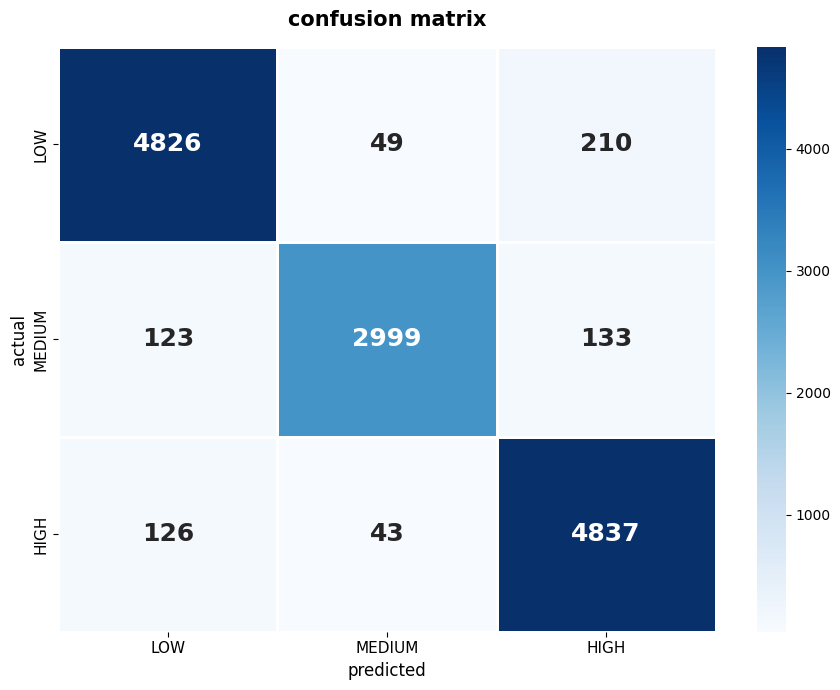

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred, labels=['LOW', 'MEDIUM', 'HIGH'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['LOW', 'MEDIUM', 'HIGH'],
            yticklabels=['LOW', 'MEDIUM', 'HIGH'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 18, 'weight': 'bold'},
            ax=ax)

ax.set_title('confusion matrix', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('actual', fontsize=12)
ax.set_xlabel('predicted', fontsize=12)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

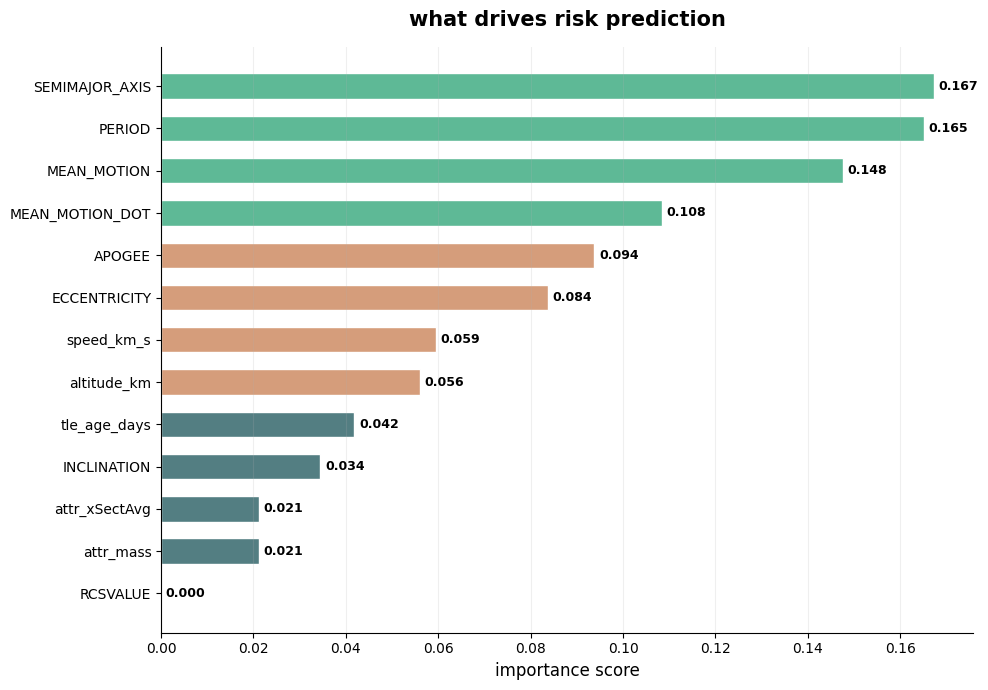

In [7]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(importance.index, importance.values, 
               color=["#5EB996" if v > 0.10 else "#d59d7b" if v > 0.05 else "#537e82" for v in importance.values],
               edgecolor='white', height=0.6)

for bar, val in zip(bars, importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('what drives risk prediction', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('importance score', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

/tmp/ipykernel_42207/285783809.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = sample_clean.groupby(['altitude_bin', 'risk_label'])['MEAN_MOTION'].mean().reset_index()


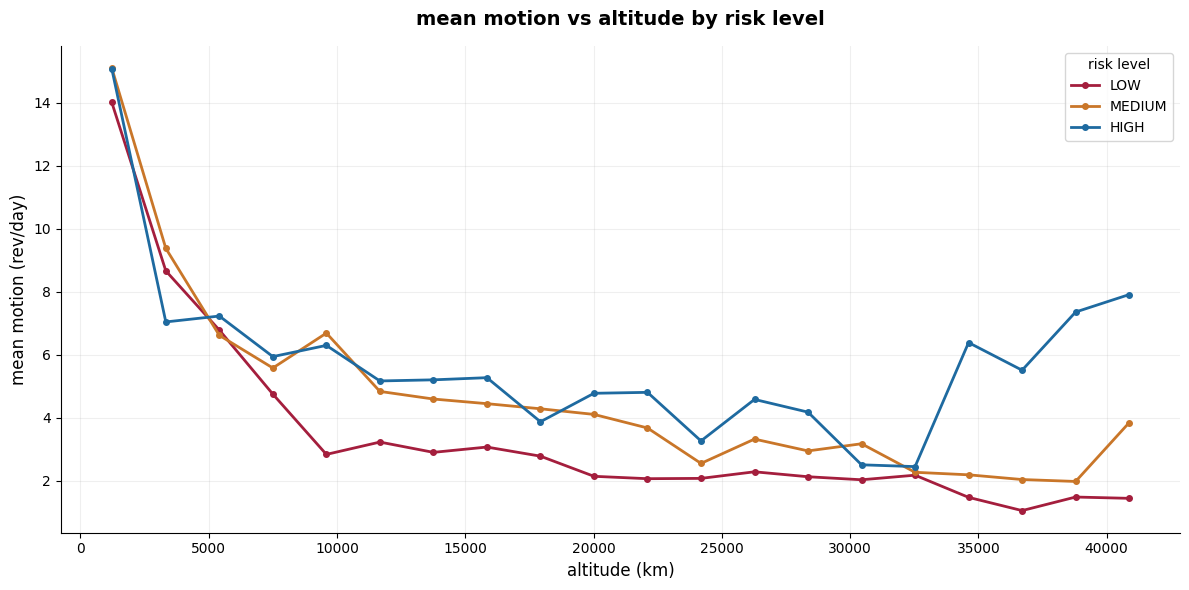

In [8]:
# bin altitude and plot mean motion trend
sample_clean = merged[(merged['altitude_km'].between(200, 42000))].copy()
sample_clean['altitude_bin'] = pd.cut(sample_clean['altitude_km'], bins=20)
sample_clean['MEAN_MOTION'] = pd.to_numeric(sample_clean['MEAN_MOTION'], errors='coerce')

trend = sample_clean.groupby(['altitude_bin', 'risk_label'])['MEAN_MOTION'].mean().reset_index()
trend['alt_mid'] = trend['altitude_bin'].apply(lambda x: x.mid)

fig, ax = plt.subplots(figsize=(12, 6))
for label, color in [('LOW', "#a41e3d"), ('MEDIUM', "#c97629"), ('HIGH', "#1e6aa0")]:
    d = trend[trend['risk_label'] == label].sort_values('alt_mid')
    ax.plot(d['alt_mid'], d['MEAN_MOTION'], color=color, label=label, linewidth=2, marker='o', markersize=4)

plt.title('mean motion vs altitude by risk level', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('altitude (km)', fontsize=12)
plt.ylabel('mean motion (rev/day)', fontsize=12)
plt.legend(title='risk level')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

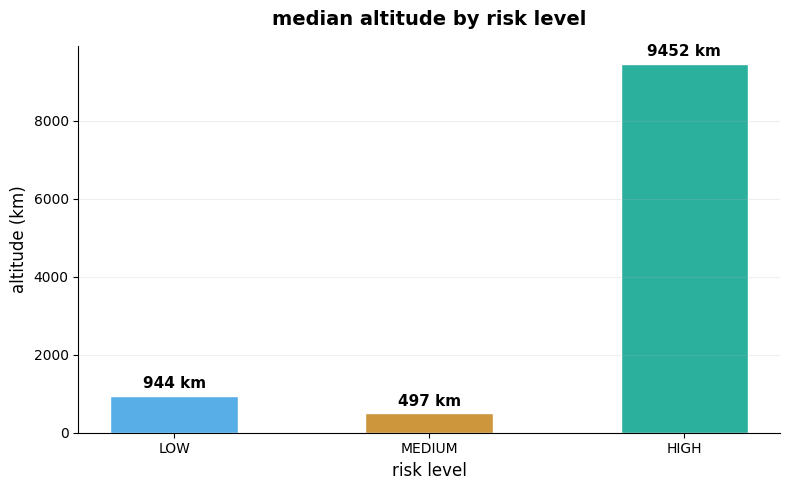

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

alt_means = merged.groupby('risk_label')['altitude_km'].median().reindex(['LOW', 'MEDIUM', 'HIGH'])
colors = ["#58aee7", "#ce963c", "#2bb09e"]

bars = ax.bar(alt_means.index, alt_means.values, color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, alt_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:.0f} km', ha='center', fontweight='bold', fontsize=11)

plt.title('median altitude by risk level', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('risk level', fontsize=12)
plt.ylabel('altitude (km)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [10]:
merged.to_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet", index=False)
print("saved with risk_label!!", merged.shape)
print(merged['risk_label'].value_counts())

saved with risk_label!! (66727, 55)
risk_label
LOW       25421
HIGH      25031
MEDIUM    16275
Name: count, dtype: int64
